# Final assignment: The BC Forest Finder

Begin by entering parameters below. Use the [VRI Data Dictionary](https://www2.gov.bc.ca/gov/content/industry/forestry/managing-our-forest-resources/forest-inventory/data-management-and-access/vri-data-standards#vridictionary) to help find desired attributes, or the table from the [BC Data Catalogue](https://catalogue.data.gov.bc.ca/dataset/vri-2024-forest-vegetation-composite-rank-1-layer-r1-/resource/0b45b37d-59e5-415f-8dff-99024c9d9264).

- The [BEC Zones and Subzones Guide](https://www.for.gov.bc.ca/hre/becweb/resources/classificationreports/subzones/index.html) may also be useful.
- For the DuckDB operations, the following pages may be useful:
    - [WHERE Clause (DuckDB)](https://duckdb.org/docs/stable/sql/query_syntax/where)
    - [SELECT Clause (DuckDB)](https://duckdb.org/docs/stable/sql/query_syntax/select)

# Inputs
## Core Inputs
These three inputs, described below, are the most important part of our analysis. 

In [1]:
# Enter a string for a location to be geocoded, such as an address or name of
#   a town.
starting_location_string = "Port Renfrew, BC"

# Enter the radius around the point to search for forest polygons (in 
#   kilometers). Note that this will be buffered by 30% when searching for a 
#   path to the polygon.
search_radius_km = 5

# Enter the desired forest stand characteristics as a SQL-style WHERE clause.
# You can copy this from the ArcGIS or QGIS "definition query".
VRI_where = """
        SPECIES_CD_1 = 'FDC' -- Species 1 is coastal Douglas Fir (FDC)
    AND PROJ_AGE_1 >= 40 -- tree species 1 age is >= 40 years
    AND PROJ_AGE_1 <= 80 -- and less than 80
    """
# An example of another clause one could add to the query:
# "BEC_ZONE_CODE = 'CWH' AND BEC_SUBZONE = 'dw' -- This selects coastal western hemlock dry maritime subzone."

## Additional inputs
If you want to tweak the output a bit more, you can optionally edit these parameters.

In [2]:
# Max Candidates: This many candidate forests will appear in the outputs
# You might want to increase this if the data is not very good in your region
max_candidates = 5

# Distance in meters between a VRI candidate centroid and the the nearest 
#   OpenStreetMap network node. You can think 
max_xcountry_distance_m = 500

# Optional: choose which fields to display on the final maps popups
# Dictionary where the keys are the field name and the values are the aliases for display on the final map
VRI_fields_dict = {
    "SPECIES_CD_1": "Dominant Tree Species Code(s)",
    "SPECIES_CD_2":  "Secondary Tree Species Code(s)",
    "PROJ_AGE_1": "Dominant Tree Species Age(s)"
}

# Analysis

In [3]:
# Install required package duckdb
%pip install duckdb

  Using cached duckdb-1.4.3-cp311-cp311-manylinux_2_26_x86_64.manylinux_2_28_x86_64.whl.metadata (4.3 kB)
Using cached duckdb-1.4.3-cp311-cp311-manylinux_2_26_x86_64.manylinux_2_28_x86_64.whl (20.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Import functions and setup paths
import bcforestfinder as bcf
import pathlib
NOTEBOOK_PATH = pathlib.Path().resolve()
OUTPUT = NOTEBOOK_PATH / "outputs"

## Get start point geometry/buffer

In [5]:
# Get a EPSG:3005 geodataframe from geocoding the starting location string
start_point_gdf = bcf.get_starting_geom(starting_location_string)

# Generate the circle search area by buffering
start_point_circle = start_point_gdf.buffer(search_radius_km * 1000)

# Assert the geom is valid and bbox is legit
assert start_point_circle.geometry.is_valid.any(), "Try a different starting point"
# Check if the start point is within a bounding box containing all of BC
assert len(start_point_circle.cx[242359:1880910, 119152:1850376]) > 0, (
    "Your starting point appears to be outside BC."
    "Try entering WGS84 lat/long coordinates.")

## Selecting the VRI polygons

- Using the geoParquet file hosted on the BC gov object storage, queried using DuckDB, then passed to a geodataframe

<div class="alert alert-block alert-info">
⚠️ <b>Common kernel error</b>
    
The following cell sometimes results in the kernel "dying unexpectedly". In this case, try restarting the notebook from the beginning and it will usually work on the second (or third) time. It usually takes about two minutes to run. 

One time it wouldn't work for me at all, but then when I tried again a few hours later it worked fine (without changing anything).

I'd like to try and solve this but I think it's a server-side issue.
</div>


In [6]:
# Return a geodataframe of the candidate VRI polygons
# Sometimes the kernel will die at this step - try restarting and run again. 
# Depending on your area this might take some time to run
vri_candidates = bcf.get_vri(VRI_where, VRI_fields_dict, start_point_circle)

# assert that the dataframe is not empty
assert len(vri_candidates) > 0, ("Warning: no candidate forest stands detected. "
    "Try one of the following methods:"
    "\nIncrease search radius"
    "\nCheck your attributes with the VRI data dictionary (linked above)")

# Display the first five VRI records to verify them
vri_candidates.head() 

,OBJECTID,SPECIES_CD_1,SPECIES_CD_2,PROJ_AGE_1,geometry
0,269946,FDC,DR,58,"MULTIPOLYGON (((1117432.273 397775.173, 111742..."
1,363044,FDC,HW,43,"MULTIPOLYGON (((1114800.779 396940.694, 111481..."
2,555463,FDC,HW,63,"MULTIPOLYGON (((1122598.484 394978.083, 112259..."
3,583279,FDC,HW,63,"MULTIPOLYGON (((1121716.194 393970.017, 112171..."
4,960463,FDC,HW,63,"MULTIPOLYGON (((1123133.35 395153.38, 1123141...."


In [7]:
# Merge adjacent polygons (dissolve)
# This will simplify the final output, although it assumes that 
vri_dissolve = bcf.dissolve_adjacent(vri_candidates)

## Find the fastest route from the start point to each candidate
Using openstreetmap data retrieved and analyzed with osmnx. The code is based on the example from the University of Helsinki [AutoGIS lesson](https://autogis-site.readthedocs.io/en/latest/lessons/lesson-6/network-analysis.html)

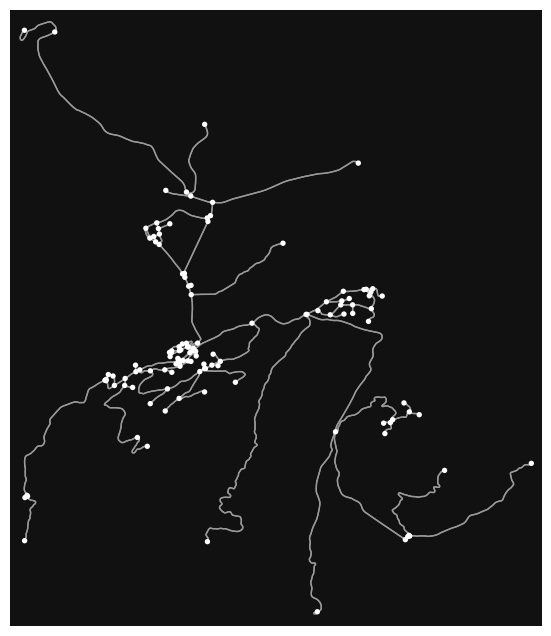

In [8]:
# Retrieve graph from openstreetmap using osmnx
graph = bcf.get_osm_network(search_radius_km, start_point_gdf)

# Plot the network graph
import osmnx as ox
fig, ax = ox.plot_graph(graph)

In [9]:
print(f"Found {len(vri_dissolve)} candidate polygons before discarding candidates too far from nodes.")
# Get shortest route to each polygon
gdf_ranked = bcf.rank_gdf(graph, vri_dissolve, start_point_gdf, max_xcountry_distance_m)

# Join back to vri_dissolve
vri_dissolve_join = vri_dissolve.merge(gdf_ranked, left_index=True, right_on="polygon_id")

# Report top candidates
top_candidates = vri_dissolve_join.sort_values('rank').iloc[0:max_candidates].dropna()

assert len(top_candidates) > 0, (
    f"No routeable polygons were found from the {len(vri_dissolve)} candidates"
    " - try increasing the maximum distance from node.")

Found 18 candidate polygons.
Discarded candidate 1.613km from node
Discarded candidate 2.548km from node
Discarded candidate 3.678km from node
Discarded candidate 2.632km from node
Discarded candidate 0.960km from node
Discarded candidate 0.518km from node
Discarded candidate 0.983km from node
Discarded candidate 1.153km from node
Discarded candidate 0.960km from node
Discarded candidate 1.389km from node
Discarded candidate 0.676km from node
Discarded candidate 1.159km from node


# Outputs
- List the candidates and their travel times
- Create and save Folium map

In [10]:
# List candidates and travel time as string:
for idx, i in top_candidates.iterrows():
    print(f"""{int(i['rank'])}: A {i.geometry.area/10000:.2f} ha stand with age(s) {i['PROJ_AGE_1']}.
    {i['travel_time_seconds']/60:.1f} minutes estimated travel time.
    {i['distance']/1000:.2f}km distance, {i['track_dis']/1000:.2f}km by rough track.
    Polygon centroid is {int(i['Cross-Country Distance'])} m from nearest network node.
    """)

1: A 3.73 ha stand with age(s) 58.
    5.3 minutes estimated travel time.
    4.34km distance, 0.00km by rough track.
    Polygon centroid is 322 m from nearest network node.
    
2: A 4.50 ha stand with age(s) 58.
    7.1 minutes estimated travel time.
    5.55km distance, 0.00km by rough track.
    Polygon centroid is 129 m from nearest network node.
    
3: A 1.24 ha stand with age(s) 73.
    9.3 minutes estimated travel time.
    4.46km distance, 0.82km by rough track.
    Polygon centroid is 282 m from nearest network node.
    
4: A 6.21 ha stand with age(s) 72,73.
    9.6 minutes estimated travel time.
    4.51km distance, 0.87km by rough track.
    Polygon centroid is 254 m from nearest network node.
    
5: A 112.48 ha stand with age(s) 58,74,63.
    19.3 minutes estimated travel time.
    8.52km distance, 2.16km by rough track.
    Polygon centroid is 429 m from nearest network node.
    


## Folium Map

In [127]:
m = bcf.getFoliumMap(top_candidates, VRI_fields_dict, graph, start_point_gdf)

# Add title
import folium
map_title = "Nearest Chanterelle-bearing forests to Port Renfew, BC, ranked by travel time"
title_html = f'''
             <h3 align="center" style="font-size:20px"><b>{map_title}</b></h3>
             '''
m.get_root().html.add_child(folium.Element(title_html))

# Save the map
m.save(OUTPUT / 'PortRenfrewChanterelles.html')

In [128]:
m

# Reflections
As you can see on this example map, the top candidate is actually across the river and not accessible - it also doesn't seem to really be a forest (data issue). The advantage of showing the map with satellite view is that the user can tell if this is a legit option.

Another example visible in this map is how the network analysis can only end on nodes, despite the track to polygon #5 going right up to the polygon center. Since the network can only end at the node at the end of that track, it shows the path going all the way to the end of the track then straight to the point. I'm not sure exactly how to fix this, but if I had more time I would like to look into it.

## Possible improvements that I didn't have time for:
- Instead of measuring to the polygon centroid, go for the nearest point on the polygon edge.
- Format the text output as a document with images and headings.
- Make the legend minimize-able (like a layer control object)
- Add other toggleable layers to the Folium map
- Make the input more user-friendly.